<hr>

# Welcome to Week 2

<hr>

<hr>

# Data wrangling
<hr>
Data wrangling is the procedure of acquiring, analysing, and manipulating raw data into a suitable format for faster processing and evaluation.
Data wrangling can be divided into the following section:

- Data loading and saving
- Data exploration
- Data processing such as missing value handling, encoding categorical values
- Data distribution
- Scaling

<hr>

### Data loading and saving

**Pandas** is a Python package providing fast, flexible, and expressive data structures designed to make working with “relational” or “labeled” data both easy and intuitive. It aims to be the fundamental high-level building block for doing practical, real-world data analysis in Python. [more details](https://pandas.pydata.org/docs/getting_started/overview.html)
<hr>

## 
#### Random data into pandas dataframe

In [28]:
import pandas as pd
import numpy as np
df = pd.DataFrame(np.random.randint(0,2000,size=(10, 6)), columns=list('ABCDEF'))
df.head()

,A,B,C,D,E,F
0,51,93,1612,243,228,1433
1,869,1786,1646,1421,1294,427
2,103,1725,1861,1161,1589,1619
3,1374,1841,1022,987,1671,1006
4,1837,1454,1413,1143,1816,901


In [29]:
test_df = pd.read_csv("https://people.sc.fsu.edu/~jburkardt/data/csv/biostats.csv")
test_df.head()

,Name,"""Sex""","""Age""","""Height (in)""","""Weight (lbs)"""
0,Alex,"""M""",41,74,170
1,Bert,"""M""",42,68,166
2,Carl,"""M""",32,70,155
3,Dave,"""M""",39,72,167
4,Elly,"""F""",30,66,124


In [30]:
data_path = "/Users/oscarwu/Desktop/SIT720_2026T1/Week_2-2/students.csv"

df = pd.read_csv(filepath_or_buffer = data_path)

In [31]:
df.columns

Index(['student-ID', 'course name'], dtype='str')

<hr>

#### Saving dataframe
<hr>

In [32]:
df.to_csv("df.csv",index=None)

<hr>

### Data exploration

Loading data and visualising data format.
<hr>

In [33]:
import pandas as pd
df=pd.read_csv("data/Advertising.csv")
df 

,TV,Radio,Newspaper,Sales,Types
0,230.1,37.8,69.2,22.1,newspaper
1,44.5,39.3,45.1,10.4,newspaper
2,17.2,45.9,69.3,9.3,electronics
3,151.5,41.3,58.5,18.5,electronics
4,180.8,10.8,58.4,12.9,newspaper
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,newspaper
196,94.2,4.9,8.1,9.7,electronics
197,177.0,9.3,6.4,12.8,electronics
198,283.6,42.0,66.2,25.5,newspaper


In [34]:
print(df.iloc[25:41,-2:].tail(20)) ## Data visulisation in tabular format

    Sales        Types
25   12.0    newspaper
26    NaN  electronics
27   15.9  electronics
28   18.9    newspaper
29   10.5    newspaper
30   21.4    newspaper
31   11.9  electronics
32    9.6  electronics
33   17.4    newspaper
34    9.5    newspaper
35   12.8  electronics
36   25.4  electronics
37   14.7    newspaper
38   10.1    newspaper
39   21.5  electronics
40   16.6  electronics


---
## https://people.sc.fsu.edu/~jburkardt/data/csv/biostats.csv

#### Understanding `iloc` — Integer Location Based Indexing

`iloc` lets you select rows and columns by their **position** (0-based integer index), just like indexing a Python list.

**Syntax:** `df.iloc[row_selection, column_selection]`

##### Selecting Rows

| Code | What it does | Key detail |
|------|-------------|------------|
| `df.iloc[0]` | Select the **first** row | Returns a single row as a Series |
| `df.iloc[0:5]` | Select rows at positions **0, 1, 2, 3, 4** | The **stop** index (5) is **excluded** — this is called *half-open* slicing |
| `df.iloc[25:41]` | Select rows at positions **25 through 40** | 41 is excluded, so you get 16 rows |

##### Selecting Rows **and** Columns

| Code | What it does |
|------|-------------|
| `df.iloc[25:41, -2:]` | Rows 25–40, **last 2 columns** |

> **Tip — Negative indexing:** `-2:` means "start from the 2nd-to-last column and go to the end". This works the same way as Python list slicing: `my_list[-2:]` gives you the last two elements.

##### Quick visual summary

```
df.iloc[ start : stop , col_start : col_stop ]
          ↑       ↑        ↑          ↑
       included  excluded  included   excluded
```

**Remember:** Python slicing is always **start ≤ position < stop** (left-inclusive, right-exclusive).

<hr>

##### Data types
<hr>

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         198 non-null    float64
 1   Radio      198 non-null    float64
 2   Newspaper  199 non-null    float64
 3   Sales      197 non-null    float64
 4   Types      200 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


<hr>

##### Data describtion such as mean, std
<hr>

In [36]:
df.describe()

,TV,Radio,Newspaper,Sales
count,198.000000,198.000000,199.000000,197.000000
mean,148.223232,23.361111,30.508543,14.055330
std,85.463201,14.889023,21.824034,5.240709
min,0.700000,0.000000,0.300000,1.600000
25%,75.150000,9.925000,12.700000,10.400000
50%,150.650000,23.450000,25.600000,12.900000
75%,219.475000,36.575000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


<hr>

### Find the missing values and replace with previous data point
<hr>

In [51]:
print("------------------------Before-------------------------------------------------------------")
print("Check any values are null-->",df.isnull().values.any())
print("-------------------------------------------------------------------------------------")
print("How many values are null in individual columns or attribute\n",df.isnull().sum())
print("-------------------------------------------------------------------------------------")

------------------------Before-------------------------------------------------------------
Check any values are null--> True
-------------------------------------------------------------------------------------
How many values are null in individual columns or attribute
 TV           2
Radio        2
Newspaper    1
Sales        3
Types        0
dtype: int64
-------------------------------------------------------------------------------------


<hr>

#### Missing value fill
<hr>

In [38]:
df2=df.copy().bfill()

In [39]:
print("---------------------- After ---------------------------------------------------------------")
print("Check any values are null-->",df2.isnull().values.any())
print("-------------------------------------------------------------------------------------")
print("How many values are null in individual columns or attribute\n",df2.isnull().sum())
print("-------------------------------------------------------------------------------------")
print(df2.iloc[25:40,:].head(20)) ## Data visulisation in tabular format

---------------------- After ---------------------------------------------------------------
Check any values are null--> False
-------------------------------------------------------------------------------------
How many values are null in individual columns or attribute
 TV           0
Radio        0
Newspaper    0
Sales        0
Types        0
dtype: int64
-------------------------------------------------------------------------------------
       TV  Radio  Newspaper  Sales        Types
25  262.9    3.5       19.5   12.0    newspaper
26  142.9   29.3       12.6   15.9  electronics
27  240.1   16.7       22.9   15.9  electronics
28  248.8   27.1       22.9   18.9    newspaper
29   70.6   16.0       40.8   10.5    newspaper
30  292.9   28.3       43.2   21.4    newspaper
31  112.9   17.4       38.6   11.9  electronics
32   97.2    1.5       30.0    9.6  electronics
33  265.6   20.0        0.3   17.4    newspaper
34   95.7    1.4        7.4    9.5    newspaper
35  290.7    4.1       

<hr>

#### Categorical value encoding
<hr>

In [40]:
df2.head()

,TV,Radio,Newspaper,Sales,Types
0,230.1,37.8,69.2,22.1,newspaper
1,44.5,39.3,45.1,10.4,newspaper
2,17.2,45.9,69.3,9.3,electronics
3,151.5,41.3,58.5,18.5,electronics
4,180.8,10.8,58.4,12.9,newspaper


<hr>


## Interger encode
<hr>

In [41]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(df2["Types"])
df2["interger label"]=integer_encoded
print(label_encoder.classes_)
# # creating instance of labelencoder
# labelencoder = LabelEncoder()
# # Assigning numerical values and storing in another column
# df2['Bridge_Types_Cat'] = labelencoder.fit_transform(df2["Types"])

['electronics' 'newspaper']


In [42]:
df2.head()

,TV,Radio,Newspaper,Sales,Types,interger label
0,230.1,37.8,69.2,22.1,newspaper,1
1,44.5,39.3,45.1,10.4,newspaper,1
2,17.2,45.9,69.3,9.3,electronics,0
3,151.5,41.3,58.5,18.5,electronics,0
4,180.8,10.8,58.4,12.9,newspaper,1


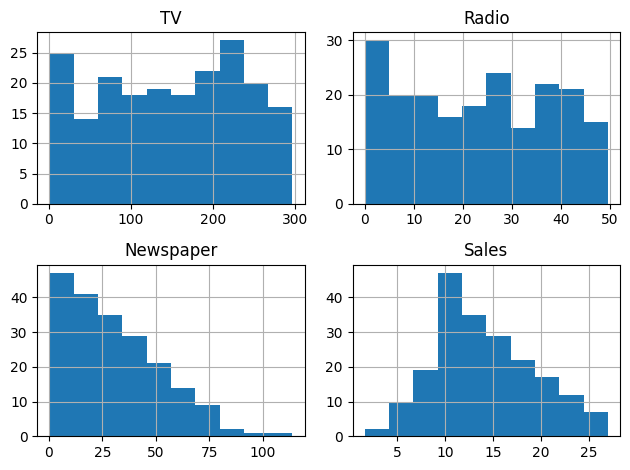

In [43]:
import matplotlib.pyplot as plt
df2[['TV', 'Radio', 'Newspaper', 'Sales']].hist()
plt.tight_layout()
plt.show()

### Data distribution

#### Scaling

<hr>

***Z-score:*** transform the features into distribution with zero mean and 1 standard deviation. Can be defined by the following equation:<br>
<span style="color:red">$$\frac{X-\mu}{\sigma}$$</span><br>
***Before scalling Mean value:***
<hr>

#### Why `ddof=0` in `.std()`?

In pandas, `.std()` uses `ddof=1` by default, which computes the **sample standard deviation** (dividing by **N − 1**). Here we explicitly set `ddof=0` to compute the **population standard deviation** (dividing by **N**).

**Sample standard deviation** (`ddof=1`, pandas default):

$$s = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(X_i - \bar{X})^2}$$

**Population standard deviation** (`ddof=0`):

$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(X_i - \mu)^2}$$

The Z-score standardisation formula uses the **population** standard deviation:

$$Z = \frac{X - \mu}{\sigma} = \frac{X - \mu}{\sqrt{\frac{1}{N}\sum_{i=1}^{N}(X_i - \mu)^2}}$$

After applying Z-score scaling, we expect:

$$\mu_Z = 0, \quad \sigma_Z = 1$$

If we mistakenly use $s$ (with $N-1$) instead of $\sigma$ (with $N$), the resulting standard deviation will be:

$$\sigma_Z = \frac{\sigma}{s} = \frac{\sqrt{1/N}}{\sqrt{1/(N-1)}} = \sqrt{\frac{N-1}{N}} \approx 0.9975 \neq 1$$

| Parameter | Divisor | Formula | After scaling, std = |
|-----------|---------|---------|----------------------|
| `ddof=0` (population) | $N$ | $\sigma = \sqrt{\frac{1}{N}\sum(X_i - \mu)^2}$ | **exactly 1.0** |
| `ddof=1` (sample, default) | $N-1$ | $s = \sqrt{\frac{1}{N-1}\sum(X_i - \bar{X})^2}$ | ≈ 0.9975 |

> **Rule of thumb:** use `ddof=1` for statistical inference (estimating from a sample); use `ddof=0` for data transformations (scaling the dataset itself).

In [44]:
print("--------------------------")
print(df2[['TV', 'Radio', 'Newspaper', 'Sales']].mean())
print("STD:")
print("--------------------------")
print(df2[['TV', 'Radio', 'Newspaper', 'Sales']].std(ddof=0))

--------------------------
TV           148.7150
Radio         23.4700
Newspaper     30.6495
Sales         14.0100
dtype: float64
STD:
--------------------------
TV           85.015908
Radio        14.823893
Newspaper    21.805492
Sales         5.228499
dtype: float64


<hr>

***After scalling Mean value:***
<hr>

In [45]:
df3=df2.copy()
df3[['TV', 'Radio', 'Newspaper']]=(df3[['TV', 'Radio', 'Newspaper']]-df3[['TV', 'Radio', 'Newspaper' ]].mean())/df3[['TV', 'Radio', 'Newspaper']].std(ddof=0)

In [46]:
print("--------------------------")
print(df3[['TV', 'Radio', 'Newspaper']].mean())
print("STD:")
print("--------------------------")
print(df3[['TV', 'Radio', 'Newspaper']].std(ddof=0))

--------------------------
TV          -3.108624e-17
Radio        7.105427e-17
Newspaper    1.776357e-17
dtype: float64
STD:
--------------------------
TV           1.0
Radio        1.0
Newspaper    1.0
dtype: float64


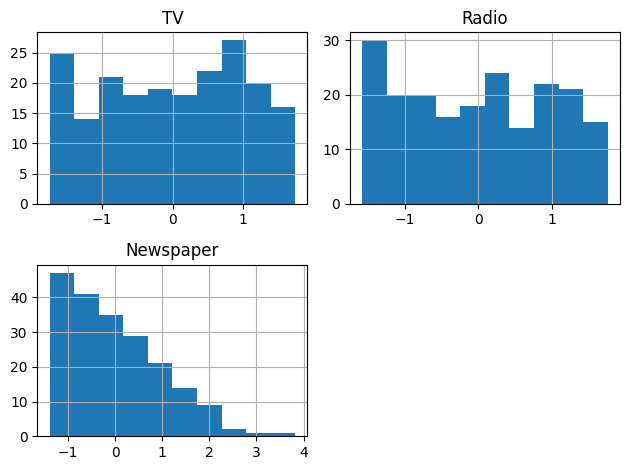

In [47]:
import matplotlib.pyplot as plt
df3[['TV', 'Radio', 'Newspaper']].hist()
plt.tight_layout()
plt.show()


<hr>

# Task
<hr>

 ### 1. Generate random 1000X2 size dataframe, where features named "student-ID","course name" and save into csv file format.
 ### 2. Class task: Load the Advertising.csv file and do the min-max scaling and display the before and after data distribution.
 
 ***Hits:*** **Minmax scaling:**  transform the features from 0 to 1. Can be defined by the following equation:<br>
<span style="color:red;font-size:50px"> $$\frac{X-min}{max-min}$$</span><br>
<hr>
<hr>

<!-- <hr>

# Task
<hr>

1. Create a timeseries data and save as txt file.
2. Load the data which is save in task-1.
3. Read "train_wbcd.csv" and print the number of features with missing entries (feature value is zero or null)
4. Fill the missing entries. For filling any feature, you can use either mean or median value of the feature values from observed entries. Explain the reason behind your choice.
5. Encode all the categorical variables and save into csv file.
6. Do the min-max scaling and display the before and after data distribution.

<hr> -->

In [60]:
pd.DataFrame(np.random.randint(4000, size=(800, 5)))

,0,1,2,3,4
0,1495,3304,1195,404,3636
1,3260,1229,3335,1028,2268
2,2605,2706,3558,2935,2733
3,3215,3197,139,116,15
4,1019,3657,2639,3339,1106
...,...,...,...,...,...
795,985,2637,3489,277,862
796,1697,195,571,250,432
797,391,1911,283,3752,2446
798,3059,3613,426,3642,2717


<hr>

# End of Week 2
<hr>

In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# task 1 – random student/course dataframe and save

ids = np.arange(1, 1001)
courses = ['Math', 'History', 'Physics', 'Chemistry', 'Biology', 'English']
course_names = np.random.choice(courses, size=1000)

df_students = pd.DataFrame({
    'student-ID': ids,
    'course name': course_names
})

df_students


,student-ID,course name
0,1,Physics
1,2,Biology
2,3,History
3,4,Physics
4,5,History
...,...,...
995,996,History
996,997,English
997,998,Chemistry
998,999,Chemistry


In [63]:
df_students.to_csv("sit720_students.csv", index= False)

In [ ]:
df_students.to_csv("students.csv", index=False)
df_students.head()

TypeError: Axes.bar() missing 2 required positional arguments: 'x' and 'height'

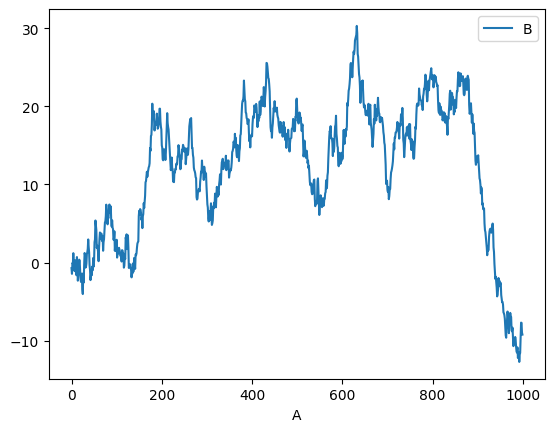

In [ ]:
df3 = pd.DataFrame(np.random.randn(1000, 2), columns=["B", "C"]).cumsum()

df3["A"] = pd.Series(list(range(len(df))))

df3.plot(x="A", y="B")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_bar = pd.read_csv("/Users/oscarwu/Desktop/SIT720_2026T1/Week_2-2/data/Advertising.csv")
print(df_bar.columns.tolist())  # verify column names
df_bar.head(10)[['TV', 'Radio', 'Newspaper']].plot.bar(figsize=(10, 4), title="Advertising Budget (First 10 Rows)")
plt.ylabel("Spending")
plt.xlabel("Row Index")
plt.tight_layout()
plt.show()

Before scaling:


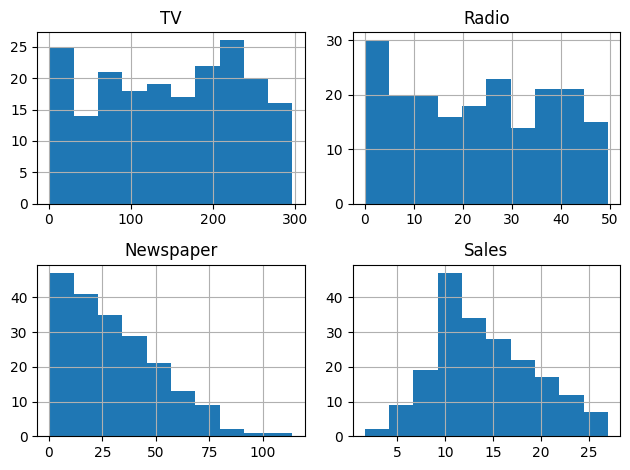

After min‑max scaling:


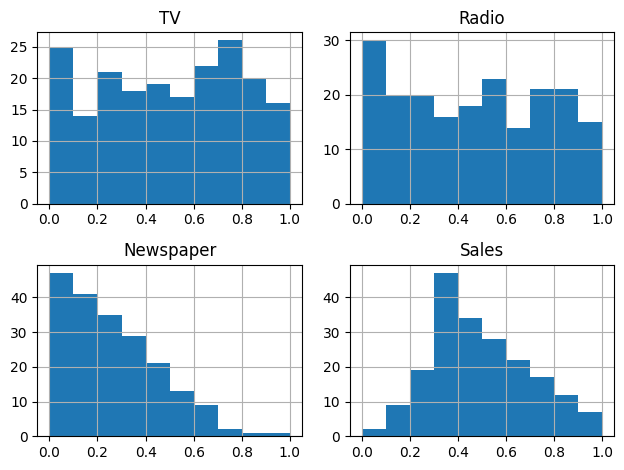

In [ ]:


# task 2 – load Advertising.csv, apply min‑max scaling and show distributions
import matplotlib.pyplot as plt

df_adv = pd.read_csv("data/Advertising.csv")

print("Before scaling:")
df_adv[['TV', 'Radio', 'Newspaper', 'Sales']].hist()
plt.tight_layout()
plt.show()

scaler = MinMaxScaler()
df_scaled = df_adv.copy()
df_scaled[['TV', 'Radio', 'Newspaper', 'Sales']] = scaler.fit_transform(
    df_scaled[['TV', 'Radio', 'Newspaper', 'Sales']]
)

print("After min‑max scaling:")
df_scaled[['TV', 'Radio', 'Newspaper', 'Sales']].hist()
plt.tight_layout()
plt.show()

In [49]:
df_adv.head()

,TV,Radio,Newspaper,Sales,Types
0,230.1,37.8,69.2,22.1,newspaper
1,44.5,39.3,45.1,10.4,newspaper
2,17.2,45.9,69.3,9.3,electronics
3,151.5,41.3,58.5,18.5,electronics
4,180.8,10.8,58.4,12.9,newspaper


In [50]:
df_scaled

,TV,Radio,Newspaper,Sales,Types
0,0.775786,0.762097,0.605981,0.807087,newspaper
1,0.148123,0.792339,0.394019,0.346457,newspaper
2,0.055800,0.925403,0.606860,0.303150,electronics
3,0.509976,0.832661,0.511873,0.665354,electronics
4,0.609063,0.217742,0.510994,0.444882,newspaper
...,...,...,...,...,...
195,0.126818,0.074597,0.118734,0.236220,newspaper
196,0.316199,0.098790,0.068602,0.318898,electronics
197,0.596212,0.187500,0.053650,0.440945,electronics
198,0.956713,0.846774,0.579595,0.940945,newspaper


In [75]:
import matplotlib.pyplot as plt
df.head(10)[['TV', 'Radio', 'Newspaper']].plot.bar(figsize=(10, 4), title="Advertising Budget (First 10 Rows)")
plt.ylabel("Spending")
plt.xlabel("Row Index")
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['TV', 'Radio', 'Newspaper'], dtype='str')] are in the [columns]"